In [ ]:
import pandas as pd
import torch 
import numpy as np
from sklearn.model_selection import train_test_split
import seaborn as sns
#top 10%

In [36]:
train_data = pd.read_csv('data/train.csv')
train_data

,id,Podcast_Name,Episode_Title,Episode_Length_minutes,Genre,Host_Popularity_percentage,Publication_Day,Publication_Time,Guest_Popularity_percentage,Number_of_Ads,Episode_Sentiment,Listening_Time_minutes
0,0,Mystery Matters,Episode 98,NaN,True Crime,74.81,Thursday,Night,NaN,0.0,Positive,31.41998
1,1,Joke Junction,Episode 26,119.80,Comedy,66.95,Saturday,Afternoon,75.95,2.0,Negative,88.01241
2,2,Study Sessions,Episode 16,73.90,Education,69.97,Tuesday,Evening,8.97,0.0,Negative,44.92531
3,3,Digital Digest,Episode 45,67.17,Technology,57.22,Monday,Morning,78.70,2.0,Positive,46.27824
4,4,Mind & Body,Episode 86,110.51,Health,80.07,Monday,Afternoon,58.68,3.0,Neutral,75.61031
...,...,...,...,...,...,...,...,...,...,...,...,...
749995,749995,Learning Lab,Episode 25,75.66,Education,69.36,Saturday,Morning,NaN,0.0,Negative,56.87058
749996,749996,Business Briefs,Episode 21,75.75,Business,35.21,Saturday,Night,NaN,2.0,Neutral,45.46242
749997,749997,Lifestyle Lounge,Episode 51,30.98,Lifestyle,78.58,Thursday,Morning,84.89,0.0,Negative,15.26000
749998,749998,Style Guide,Episode 47,108.98,Lifestyle,45.39,Thursday,Morning,93.27,0.0,Negative,100.72939


In [37]:
nan_count = train_data.isna().sum()
print(nan_count[nan_count > 0])

Episode_Length_minutes          87093
Guest_Popularity_percentage    146030
Number_of_Ads                       1
dtype: int64


In [38]:
train_data['Episode_Length_minutes'] = train_data['Episode_Length_minutes'].fillna(train_data['Episode_Length_minutes'].mode()[0])
train_data['Guest_Popularity_percentage'] = train_data['Guest_Popularity_percentage'].fillna(train_data['Guest_Popularity_percentage'].mode()[0])

In [39]:
train_data.dropna(inplace=True)

In [40]:
nan_count = train_data.isna().sum()
print(nan_count[nan_count > 0])

Series([], dtype: int64)


In [41]:
train_data

,id,Podcast_Name,Episode_Title,Episode_Length_minutes,Genre,Host_Popularity_percentage,Publication_Day,Publication_Time,Guest_Popularity_percentage,Number_of_Ads,Episode_Sentiment,Listening_Time_minutes
0,0,Mystery Matters,Episode 98,6.60,True Crime,74.81,Thursday,Night,68.53,0.0,Positive,31.41998
1,1,Joke Junction,Episode 26,119.80,Comedy,66.95,Saturday,Afternoon,75.95,2.0,Negative,88.01241
2,2,Study Sessions,Episode 16,73.90,Education,69.97,Tuesday,Evening,8.97,0.0,Negative,44.92531
3,3,Digital Digest,Episode 45,67.17,Technology,57.22,Monday,Morning,78.70,2.0,Positive,46.27824
4,4,Mind & Body,Episode 86,110.51,Health,80.07,Monday,Afternoon,58.68,3.0,Neutral,75.61031
...,...,...,...,...,...,...,...,...,...,...,...,...
749995,749995,Learning Lab,Episode 25,75.66,Education,69.36,Saturday,Morning,68.53,0.0,Negative,56.87058
749996,749996,Business Briefs,Episode 21,75.75,Business,35.21,Saturday,Night,68.53,2.0,Neutral,45.46242
749997,749997,Lifestyle Lounge,Episode 51,30.98,Lifestyle,78.58,Thursday,Morning,84.89,0.0,Negative,15.26000
749998,749998,Style Guide,Episode 47,108.98,Lifestyle,45.39,Thursday,Morning,93.27,0.0,Negative,100.72939


<Axes: ylabel='Episode_Length_minutes'>

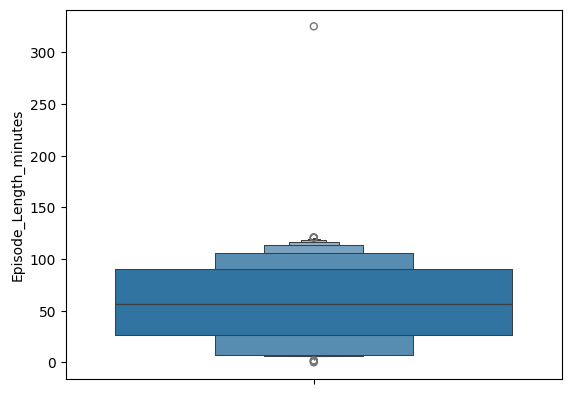

In [42]:
sns.boxenplot(train_data['Episode_Length_minutes'])

<Axes: ylabel='Listening_Time_minutes'>

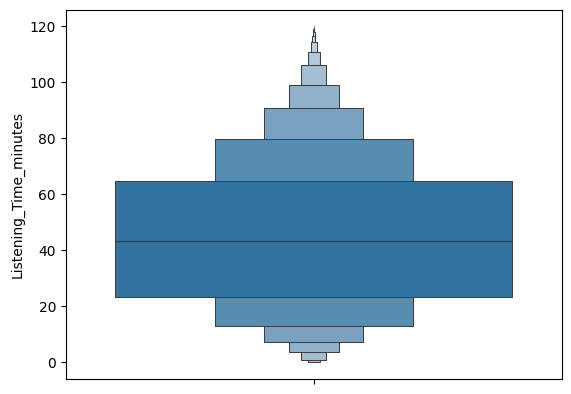

In [43]:
sns.boxenplot(train_data['Listening_Time_minutes'])

In [44]:
def winsorize(df, column, upper, lower):
    col_df = df[column]
    
    perc_upper = np.percentile(df[column],upper)
    perc_lower = np.percentile(df[column],lower)
    
    df[column] = np.where(df[column] >= perc_upper, 
                          perc_upper, 
                          df[column])
    
    df[column] = np.where(df[column] <= perc_lower, 
                          perc_lower, 
                          df[column])
    
    return df


In [45]:
train_data = winsorize(train_data,'Episode_Length_minutes',95,5)
train_data = winsorize(train_data,'Listening_Time_minutes',95,5)

In [46]:
train_data.drop(['id','Podcast_Name','Episode_Title'],axis=1,inplace=True)
train_data

,Episode_Length_minutes,Genre,Host_Popularity_percentage,Publication_Day,Publication_Time,Guest_Popularity_percentage,Number_of_Ads,Episode_Sentiment,Listening_Time_minutes
0,6.60,True Crime,74.81,Thursday,Night,68.53,0.0,Positive,31.41998
1,114.66,Comedy,66.95,Saturday,Afternoon,75.95,2.0,Negative,88.01241
2,73.90,Education,69.97,Tuesday,Evening,8.97,0.0,Negative,44.92531
3,67.17,Technology,57.22,Monday,Morning,78.70,2.0,Positive,46.27824
4,110.51,Health,80.07,Monday,Afternoon,58.68,3.0,Neutral,75.61031
...,...,...,...,...,...,...,...,...,...
749995,75.66,Education,69.36,Saturday,Morning,68.53,0.0,Negative,56.87058
749996,75.75,Business,35.21,Saturday,Night,68.53,2.0,Neutral,45.46242
749997,30.98,Lifestyle,78.58,Thursday,Morning,84.89,0.0,Negative,15.26000
749998,108.98,Lifestyle,45.39,Thursday,Morning,93.27,0.0,Negative,93.67793


In [47]:
train_data = pd.get_dummies(train_data)

In [48]:
from sklearn.preprocessing import StandardScaler

std = StandardScaler()

X = train_data.drop('Listening_Time_minutes',axis=1)
y = train_data['Listening_Time_minutes']

X = std.fit_transform(X)

x_train, x_test, y_train, y_test = train_test_split(X,y, test_size=0.2,random_state=7)


In [49]:
x_train

array([[ 1.28020107,  0.04415918, -0.7761364 , ..., -0.70735145,
        -0.7098479 ,  1.42020264],
       [-1.26828308, -1.1699325 , -1.01157182, ..., -0.70735145,
         1.4087525 , -0.70412487],
       [-0.89366984, -0.44025334,  0.96494654, ..., -0.70735145,
         1.4087525 , -0.70412487],
       ...,
       [ 1.37601293, -1.53673946,  0.49825277, ...,  1.41372438,
        -0.7098479 , -0.70412487],
       [ 0.64739714,  0.12635192,  1.19202781, ..., -0.70735145,
         1.4087525 , -0.70412487],
       [ 1.28326482, -0.15476473,  0.49825277, ..., -0.70735145,
        -0.7098479 ,  1.42020264]], shape=(599999, 28))

In [50]:
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV,KFold
from sklearn.metrics import mean_squared_error

xgb = XGBRegressor(use_label_encoder=False, eval_metric='logloss')

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5],
    'learning_rate': [ 0.1],
    'subsample': [1.0],
    'colsample_bytree': [1.0],
    'gamma': [0, 1]
}

cv = KFold(n_splits=5, shuffle=True, random_state=7)

# Grid search with cross-validation
grid_search = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    scoring='neg_root_mean_squared_error',  # RMSE
    n_jobs=-1,
    cv=cv,
    verbose=1
)

# Fit the model
grid_search.fit(x_train, y_train)

# Best parameters and CV RMSE
print("Best parameters:", grid_search.best_params_)
print("Best CV RMSE:", -grid_search.best_score_)  # Negated to get positive RMSE

# Test set evaluation
best_model = grid_search.best_estimator_
y_pred = best_model.predict(x_test)

rmse_test = mean_squared_error(y_test, y_pred)
print("Test RMSE:", rmse_test)

Fitting 5 folds for each of 8 candidates, totalling 40 fits


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [16:16:55] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [16:16:55] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [16:16:55] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [16:16:55] WARN

Best parameters: {'colsample_bytree': 1.0, 'gamma': 1, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'subsample': 1.0}
Best CV RMSE: 12.823537037534134
Test RMSE: 164.8122150725991


In [17]:
from catboost import CatBoostRegressor
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.metrics import mean_squared_error

cat = CatBoostRegressor(verbose=0)

param_grid = {
    'iterations': [300],
    'depth': [10],
    'learning_rate': [ 0.1],
    'l2_leaf_reg': [1,3]
}
# Total = 2 × 2 × 3 × 2 = 24 combinations × 5 folds = 120 fits (efficient)

cv = KFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=cat,
    param_grid=param_grid,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    cv=cv,
    verbose=1
)

grid_search.fit(x_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best CV RMSE:", -grid_search.best_score_)

best_model = grid_search.best_estimator_
y_pred = best_model.predict(x_test)
rmse_test = mean_squared_error(y_test, y_pred)
print("Test RMSE:", rmse_test)

Fitting 5 folds for each of 2 candidates, totalling 10 fits
Best parameters: {'depth': 10, 'iterations': 300, 'l2_leaf_reg': 3, 'learning_rate': 0.1}
Best CV RMSE: 12.681084501602623
Test RMSE: 161.2009554624925


In [51]:
test_data = pd.read_csv('data/test.csv')
test_data

,id,Podcast_Name,Episode_Title,Episode_Length_minutes,Genre,Host_Popularity_percentage,Publication_Day,Publication_Time,Guest_Popularity_percentage,Number_of_Ads,Episode_Sentiment
0,750000,Educational Nuggets,Episode 73,78.96,Education,38.11,Saturday,Evening,53.33,1.0,Neutral
1,750001,Sound Waves,Episode 23,27.87,Music,71.29,Sunday,Morning,NaN,0.0,Neutral
2,750002,Joke Junction,Episode 11,69.10,Comedy,67.89,Friday,Evening,97.51,0.0,Positive
3,750003,Comedy Corner,Episode 73,115.39,Comedy,23.40,Sunday,Morning,51.75,2.0,Positive
4,750004,Life Lessons,Episode 50,72.32,Lifestyle,58.10,Wednesday,Morning,11.30,2.0,Neutral
...,...,...,...,...,...,...,...,...,...,...,...
249995,999995,Mind & Body,Episode 100,21.05,Health,65.77,Saturday,Evening,96.40,3.0,Negative
249996,999996,Joke Junction,Episode 85,85.50,Comedy,41.47,Saturday,Night,30.52,2.0,Negative
249997,999997,Joke Junction,Episode 63,12.11,Comedy,25.92,Thursday,Evening,73.69,1.0,Neutral
249998,999998,Market Masters,Episode 46,113.46,Business,43.47,Friday,Night,93.59,3.0,Positive


In [52]:
nan_count = train_data.isna().sum()
print(nan_count[nan_count > 0])

Series([], dtype: int64)


In [53]:
test_data.drop(['id','Podcast_Name','Episode_Title'],axis=1,inplace=True)
test_data

,Episode_Length_minutes,Genre,Host_Popularity_percentage,Publication_Day,Publication_Time,Guest_Popularity_percentage,Number_of_Ads,Episode_Sentiment
0,78.96,Education,38.11,Saturday,Evening,53.33,1.0,Neutral
1,27.87,Music,71.29,Sunday,Morning,NaN,0.0,Neutral
2,69.10,Comedy,67.89,Friday,Evening,97.51,0.0,Positive
3,115.39,Comedy,23.40,Sunday,Morning,51.75,2.0,Positive
4,72.32,Lifestyle,58.10,Wednesday,Morning,11.30,2.0,Neutral
...,...,...,...,...,...,...,...,...
249995,21.05,Health,65.77,Saturday,Evening,96.40,3.0,Negative
249996,85.50,Comedy,41.47,Saturday,Night,30.52,2.0,Negative
249997,12.11,Comedy,25.92,Thursday,Evening,73.69,1.0,Neutral
249998,113.46,Business,43.47,Friday,Night,93.59,3.0,Positive


In [54]:
test_data = pd.get_dummies(test_data)
test_data

,Episode_Length_minutes,Host_Popularity_percentage,Guest_Popularity_percentage,Number_of_Ads,Genre_Business,Genre_Comedy,Genre_Education,Genre_Health,Genre_Lifestyle,Genre_Music,...,Publication_Day_Thursday,Publication_Day_Tuesday,Publication_Day_Wednesday,Publication_Time_Afternoon,Publication_Time_Evening,Publication_Time_Morning,Publication_Time_Night,Episode_Sentiment_Negative,Episode_Sentiment_Neutral,Episode_Sentiment_Positive
0,78.96,38.11,53.33,1.0,False,False,True,False,False,False,...,False,False,False,False,True,False,False,False,True,False
1,27.87,71.29,NaN,0.0,False,False,False,False,False,True,...,False,False,False,False,False,True,False,False,True,False
2,69.10,67.89,97.51,0.0,False,True,False,False,False,False,...,False,False,False,False,True,False,False,False,False,True
3,115.39,23.40,51.75,2.0,False,True,False,False,False,False,...,False,False,False,False,False,True,False,False,False,True
4,72.32,58.10,11.30,2.0,False,False,False,False,True,False,...,False,False,True,False,False,True,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
249995,21.05,65.77,96.40,3.0,False,False,False,True,False,False,...,False,False,False,False,True,False,False,True,False,False
249996,85.50,41.47,30.52,2.0,False,True,False,False,False,False,...,False,False,False,False,False,False,True,True,False,False
249997,12.11,25.92,73.69,1.0,False,True,False,False,False,False,...,True,False,False,False,True,False,False,False,True,False
249998,113.46,43.47,93.59,3.0,True,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,True


In [55]:
# Since you've already one-hot encoded the test data
test_processed = test_data.copy()

# Make sure all columns from training data exist in test data
missing_cols = set(train_data.columns) - set(test_processed.columns) - {'Listening_Time_minutes'}
for col in missing_cols:
    test_processed[col] = 0
    
# Ensure columns are in the same order as training data
X_cols = [col for col in train_data.columns if col != 'Listening_Time_minutes']
test_processed = test_processed[X_cols]

# Now apply standardization and predict
X_test = std.transform(test_processed)
preds = grid_search.predict(X_test)

# Create submission dataframe
# Usually Kaggle requires the original IDs, so we might need to use them
# Assuming your original test data had 'id' column before you dropped it
original_test_data = pd.read_csv('data/test.csv')
submission = pd.DataFrame({
    'id': original_test_data['id'],
    'Listening_Time_minutes': preds
})

# Save submission
submission.to_csv('submission.csv', index=False)

In [26]:
preds.shape, test_data.shape

((749999,), (250000, 8))